In [1]:
import os, sys, random, numpy as np, pandas as pd, torch
from sklearn.model_selection import StratifiedGroupKFold

# Reproducibility
def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s); torch.backends.cudnn.deterministic = True
set_seed(42)

DATA_DIR   = os.path.join("..", "data")
IMAGES_DIR = os.path.join(DATA_DIR, "HAM_10000_images")
META_CSV   = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

print("Python:", sys.version.split()[0])
print("CUDA available:", torch.cuda.is_available())
print("CSV exists?", os.path.exists(META_CSV))
print("Images dir exists?", os.path.isdir(IMAGES_DIR))

meta = pd.read_csv(META_CSV)
print("Rows in metadata:", len(meta))
meta.head()


Python: 3.10.18
CUDA available: False
CSV exists? True
Images dir exists? True
Rows in metadata: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [2]:
print(meta.isna().sum())

meta['filename'] = meta['image_id'].astype(str)+".jpg"
meta['filepath'] = meta['filename'].apply(lambda x: os.path.join(IMAGES_DIR, x))

missing = meta[~meta['filepath'].apply(os.path.exists)]
print("Λείπουν αρχεία:", len(missing))

dx_names = {
    "akiec":"Actinic keratoses / intraepithelial carcinoma",
    "bcc":"Basal cell carcinoma",
    "bkl":"Benign keratosis-like lesions",
    "df":"Dermatofibroma",
    "mel":"Melanoma",
    "nv":"Melanocytic nevi",
    "vasc":"Vascular lesions",
}
meta['dx_full'] = meta['dx'].map(dx_names)

meta['dx'].value_counts()


lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64
Λείπουν αρχεία: 0


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [3]:
X = meta['image_id'].values
y = meta['dx'].values
groups = meta['lesion_id'].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, valtest_idx = next(sgkf.split(X, y, groups))
train_df   = meta.iloc[train_idx].copy()
valtest_df = meta.iloc[valtest_idx].copy()

sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
vt_X, vt_y, vt_g = valtest_df['image_id'].values, valtest_df['dx'].values, valtest_df['lesion_id'].values
val_idx, test_idx = next(sgkf2.split(vt_X, vt_y, vt_g))
val_df  = valtest_df.iloc[val_idx].copy()
test_df = valtest_df.iloc[test_idx].copy()

for d, name in [(train_df,'train'), (val_df,'val'), (test_df,'test')]:
    d['split'] = name

meta_split = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)
print(len(train_df), len(val_df), len(test_df))

# Save the split (ξεκάθαρα νέο αρχείο για να μη μπερδευτείς)
meta_split[['image_id','lesion_id','dx','split']].to_csv('ham10000_split_v2.csv', index=False)
meta_split.head()


8001 1009 1005


,lesion_id,image_id,dx,dx_type,age,sex,localization,filename,filepath,dx_full,split
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,ISIC_0027419.jpg,..\data\HAM_10000_images\ISIC_0027419.jpg,Benign keratosis-like lesions,train
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,ISIC_0025030.jpg,..\data\HAM_10000_images\ISIC_0025030.jpg,Benign keratosis-like lesions,train
2,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,ISIC_0031633.jpg,..\data\HAM_10000_images\ISIC_0031633.jpg,Benign keratosis-like lesions,train
3,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,ISIC_0027850.jpg,..\data\HAM_10000_images\ISIC_0027850.jpg,Benign keratosis-like lesions,train
4,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,ISIC_0029176.jpg,..\data\HAM_10000_images\ISIC_0029176.jpg,Benign keratosis-like lesions,train


In [4]:
def counts(df): 
    c = df['dx'].value_counts().sort_index()
    return c.to_frame('count')

print("TRAIN\n", counts(train_df))
print("\nVAL\n", counts(val_df))
print("\nTEST\n", counts(test_df))


TRAIN
        count
dx          
akiec    259
bcc      414
bkl      894
df        93
mel      891
nv      5342
vasc     108

VAL
        count
dx          
akiec     44
bcc       47
bkl       81
df        14
mel      108
nv       696
vasc      19

TEST
        count
dx          
akiec     24
bcc       53
bkl      124
df         8
mel      114
nv       667
vasc      15


In [5]:
CLASS_NAMES = ['akiec','bcc','bkl','df','mel','nv','vasc']
class_to_idx = {c:i for i,c in enumerate(CLASS_NAMES)}
idx_to_class = {i:c for c,i in class_to_idx.items()}
class_to_idx


{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

In [6]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image

IMG_SIZE = 128

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), value='random'),
])

eval_tfms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class SkinDataset(Dataset):
    def __init__(self, df, transform=None, class_to_idx=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = class_to_idx
    def __len__(self): 
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row['filepath']).convert('RGB')
        if self.transform: img = self.transform(img)
        label = self.class_to_idx[row['dx']]
        return img, label, row['image_id']


In [7]:
train_ds = SkinDataset(train_df, transform=train_tfms, class_to_idx=class_to_idx)
val_ds   = SkinDataset(val_df,   transform=eval_tfms,  class_to_idx=class_to_idx)
test_ds  = SkinDataset(test_df,  transform=eval_tfms,  class_to_idx=class_to_idx)

BATCH_SIZE  = 32
HAS_CUDA    = torch.cuda.is_available()
PIN_MEMORY  = False          # χωρίς CUDA
NUM_WORKERS = 0              # Windows: 0 (σε Linux δοκίμασε 2–4)

# Sampler με ελαφρά εξομάλυνση
class_counts = train_df['dx'].value_counts().to_dict()
class_weights = {c: 1.0/np.log(1.02 + class_counts[c]) for c in class_counts}
sample_weights = train_df['dx'].map(class_weights).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                      num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

len(train_ds), len(val_ds), len(test_ds)


(8001, 1009, 1005)

Batch images: torch.Size([32, 3, 128, 128])
Batch labels: torch.Size([32])
Unique labels in batch: tensor([1, 2, 3, 4, 5])


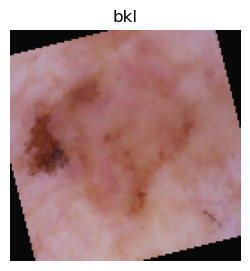

In [8]:
xb, yb, ids = next(iter(train_dl))
print("Batch images:", xb.shape)   # αναμένουμε [B, 3, 128, 128]
print("Batch labels:", yb.shape)
print("Unique labels in batch:", torch.unique(yb))

import matplotlib.pyplot as plt
def show_tensor_image(t):
    t = t.detach().cpu().clone()
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    t = (t*std + mean).clamp(0,1).permute(1,2,0).numpy()
    plt.imshow(t); plt.axis('off')

plt.figure(figsize=(3,3))
show_tensor_image(xb[0])
plt.title(idx_to_class[int(yb[0])])
plt.show()


In [9]:
ti, vi, te = set(train_df['lesion_id']), set(val_df['lesion_id']), set(test_df['lesion_id'])
print("Overlap train↔val:",  len(ti & vi))
print("Overlap train↔test:", len(ti & te))
print("Overlap val↔test:",   len(vi & te))


Overlap train↔val: 0
Overlap train↔test: 0
Overlap val↔test: 0
